# Notebook 10 — Real-World Field Test (optional)

## Goal

A qualitative test of the project's image classifier — the CNN
EfficientNetB3 from notebook 07 — on **personal field photographs** taken at
the Krasnovo site (12 and 14 May 2026, the period when rust was observed).

## Honest Framing (read first)

These photos are **out-of-distribution** for the model:

- The CNN was trained on **cropped, single-leaf images at 224×224**.
- These are **whole-plant field shots** — multiple compound leaves, hands,
  grass and soil in frame, natural lighting. This is a strong **domain
  shift**.

The photos are also **unlabelled**, so this notebook does **not** compute
accuracy. It is a qualitative diagnostic: we look at the model's predictions
and confidence, and interpret *how* and *why* it behaves on real field input
— explicitly so a reader understands the model was not trained on such
photos and that any weak performance is expected domain shift, not a defect.

## What This Notebook Does

1. Loads the trained CNN (`07_cnn_efficientnetb3_final.keras`).
2. Runs inference on all personal photos (with correct EXIF orientation and
   the same [0–255] RGB / 224×224 input the model was trained on).
3. Shows each photo with its predicted class and confidence.
4. Summarises the prediction distribution.
5. Concludes honestly: behaviour, domain-shift diagnosis, and concrete next
   steps to make the model field-ready.

In [5]:
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

print("1/3  Importing TensorFlow", flush=True)
t = time.time()
import tensorflow as tf
from tensorflow import keras
print(f"     TF {tf.__version__} imported in {time.time() - t:.0f}s", flush=True)

# ---- Paths ----
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
MODELS_DIR   = PROJECT_ROOT / "models"
MODEL_PATH   = MODELS_DIR / "07_cnn_efficientnetb3_final.keras"
PERSONAL_DIR = PROJECT_ROOT / "datasets" / "pavel_ivanov_personal_data"
assert MODEL_PATH.exists(),   f"Missing model: {MODEL_PATH}"
assert PERSONAL_DIR.exists(), f"Missing photos dir: {PERSONAL_DIR}"

CLASS_NAMES = ["black_spot", "downy_mildew", "healthy_leaf", "insect_damage",
               "powdery_mildew", "rose_mosaic", "rose_rust"]
IMAGE_SIZE = (224, 224)
photo_paths = sorted(PERSONAL_DIR.glob("*.jpg"))
print(f"2/3  Found {len(photo_paths)} photos.", flush=True)

print("3/3  Loading the CNN model", flush=True)
t = time.time()
model = keras.models.load_model(MODEL_PATH)
print(f"     Model loaded in {time.time() - t:.0f}s", flush=True)

print(f"\nSetup ready")
print(f"  Model input shape : {model.input_shape}")
print(f"  Output units      : {model.output_shape[-1]} (expected {len(CLASS_NAMES)})")
assert model.output_shape[-1] == len(CLASS_NAMES)

# ============================================================
# Image loader - preprocess one photo to match the training input
# (EXIF-corrected, RGB, 224x224, [0-255]; used by the sanity check and the
#  field inference below)
# ============================================================
def load_image(path, size=IMAGE_SIZE):
    img = Image.open(path)
    img = ImageOps.exif_transpose(img)        # honour phone EXIF rotation
    img = img.convert("RGB").resize(size)
    return np.array(img, dtype="float32")     # 0-255 (model expects this)


1/3  Importing TensorFlow
     TF 2.21.0 imported in 0s
2/3  Found 49 photos.
3/3  Loading the CNN model
     Model loaded in 3s

Setup ready
  Model input shape : (None, 224, 224, 3)
  Output units      : 7 (expected 7)


## Verifying the Inference Pipeline First

The field photos are unlabelled, so I cannot prove whether any individual
field prediction is correct. But before interpreting those predictions at
all, I must rule out a more basic risk: **that the model is being applied
incorrectly here** (wrong loading, wrong preprocessing, a version mismatch
after moving the `.keras` file from Colab to this machine).

To do that, I run the loaded model — through the *exact same* `load_image`
preprocessing used for the field photos — on a stratified sample of the
**labelled** test set from notebook 02. If the accuracy reproduces notebook
07's result (~0.98), the pipeline is faithful, and I can trust that the
field-photo predictions are the model's genuine output.

This cleanly separates two questions:

1. *Is our inference pipeline correct?* — answered here, on labelled data.
2. *Does the model generalise to real field photos?* — the qualitative
   question the rest of the notebook explores, where any weakness is
   attributable to domain shift rather than a bug.


In [6]:
# ============================================================
# PIPELINE SANITY CHECK — run the model on LABELLED test images.
# If accuracy ~ 0.98 (matching notebook 07), our loading + preprocessing
# are faithful, so errors on the field photos are domain shift, not bugs.
# ============================================================
import random

TEST_DIR    = PROJECT_ROOT / "data" / "processed" / "images" / "test"
N_PER_CLASS = 40                      # stratified subset for speed on CPU
rng = random.Random(42)

sample_paths, sample_labels = [], []
for ci, cls in enumerate(CLASS_NAMES):
    files = sorted((TEST_DIR / cls).glob("*"))
    pick = rng.sample(files, min(N_PER_CLASS, len(files)))
    sample_paths  += pick
    sample_labels += [ci] * len(pick)
sample_labels = np.array(sample_labels)

print(f"Running the model on {len(sample_paths)} labelled test images "
      f"(up to {N_PER_CLASS}/class)...")
Xs      = np.stack([load_image(p) for p in sample_paths])
probs_s = model.predict(Xs, verbose=0)
pred_s  = probs_s.argmax(axis=1)
acc     = float((pred_s == sample_labels).mean())

print(f"\nAccuracy on labelled test sample : {acc:.4f}")
print(f"Notebook 07 full-test accuracy   : 0.9822  (reference)")
print("\nPer-class accuracy:")
for ci, cls in enumerate(CLASS_NAMES):
    m = sample_labels == ci
    print(f"  {cls:<16}: {(pred_s[m] == ci).mean():.2f}  ({int(m.sum())} imgs)")

Running the model on 280 labelled test images (up to 40/class)...

Accuracy on labelled test sample : 0.9964
Notebook 07 full-test accuracy   : 0.9822  (reference)

Per-class accuracy:
  black_spot      : 1.00  (40 imgs)
  downy_mildew    : 1.00  (40 imgs)
  healthy_leaf    : 1.00  (40 imgs)
  insect_damage   : 1.00  (40 imgs)
  powdery_mildew  : 0.97  (40 imgs)
  rose_mosaic     : 1.00  (40 imgs)
  rose_rust       : 1.00  (40 imgs)


### Observations

The model scores **0.9964** on 280 labelled test images (per-class ~1.00),
reproducing — and slightly exceeding, on this balanced subset — the 0.9822
full-test accuracy of notebook 07. This **proves the inference pipeline is
faithful**: the model loads correctly and our `load_image` preprocessing
(EXIF fix, RGB, 224×224, [0–255]) matches the training input.

Consequently, the field-photo predictions are genuine model outputs, not a
preprocessing bug. Notably, **rose_rust accuracy is 1.00 in-distribution** —
the model clearly *can* recognise rust on cropped single leaves. Any
weakness on the whole-plant field photos is therefore attributable to
**domain shift**, not to an inability to detect the disease.

## Loading the Photos and Running Inference

Each photo is loaded with its EXIF orientation honoured (phone photos often
carry a rotation flag), converted to RGB, resized to 224×224, and kept in the
**[0–255] range** — exactly the input the EfficientNetB3 model was trained on
(its preprocessing is built in; no manual rescaling). All 49 photos are run
through the model in one batch.

In [7]:
# ============================================================
# Build the batch and run inference
# (load_image is defined in the setup cell)
# ============================================================
X = np.stack([load_image(p) for p in photo_paths])    # (49, 224, 224, 3)
print(f"Image batch shape: {X.shape}, value range [{X.min():.0f}, {X.max():.0f}]")

probs      = model.predict(X, verbose=0)               # (49, 7)
pred_idx   = probs.argmax(axis=1)
pred_conf  = probs.max(axis=1)
pred_class = [CLASS_NAMES[i] for i in pred_idx]

# ============================================================
# Per-photo predictions (sanity / qualitative read)
# ============================================================
print("\nPredictions per photo:")
for p, c, cf in zip(photo_paths, pred_class, pred_conf):
    print(f"  {p.name:<30} -> {c:<16} ({cf:.2f})")

# ============================================================
# Confidence overview
# ============================================================
print(f"\nMean confidence : {pred_conf.mean():.2f}")
print(f"Median confidence: {np.median(pred_conf):.2f}")

Image batch shape: (49, 224, 224, 3), value range [0, 255]

Predictions per photo:
  IMG_20260512_165004.jpg        -> healthy_leaf     (0.77)
  IMG_20260512_165016.jpg        -> healthy_leaf     (1.00)
  IMG_20260512_165022.jpg        -> healthy_leaf     (0.97)
  IMG_20260514_164457.jpg        -> healthy_leaf     (0.73)
  IMG_20260514_164501.jpg        -> healthy_leaf     (0.94)
  IMG_20260514_164504.jpg        -> healthy_leaf     (1.00)
  IMG_20260514_164509.jpg        -> black_spot       (0.78)
  IMG_20260514_164515.jpg        -> powdery_mildew   (0.83)
  IMG_20260514_164527.jpg        -> healthy_leaf     (0.94)
  IMG_20260514_164530.jpg        -> healthy_leaf     (0.95)
  IMG_20260514_164540.jpg        -> powdery_mildew   (0.97)
  IMG_20260514_164546.jpg        -> healthy_leaf     (0.51)
  IMG_20260514_164600.jpg        -> healthy_leaf     (0.61)
  IMG_20260514_164607.jpg        -> powdery_mildew   (0.91)
  IMG_20260514_164612.jpg        -> powdery_mildew   (0.68)
  IMG_20260514_16

## Visualisation: Predictions on All 49 Field Photos

Each personal photo is shown at the 224x224 resolution the model actually
sees, titled with the predicted class and confidence. The title colour flags
the confidence band (green high, orange medium, red low). This is where the
domain-shift behaviour becomes visible by eye - including cases where a clear
rust symptom is read as another class.


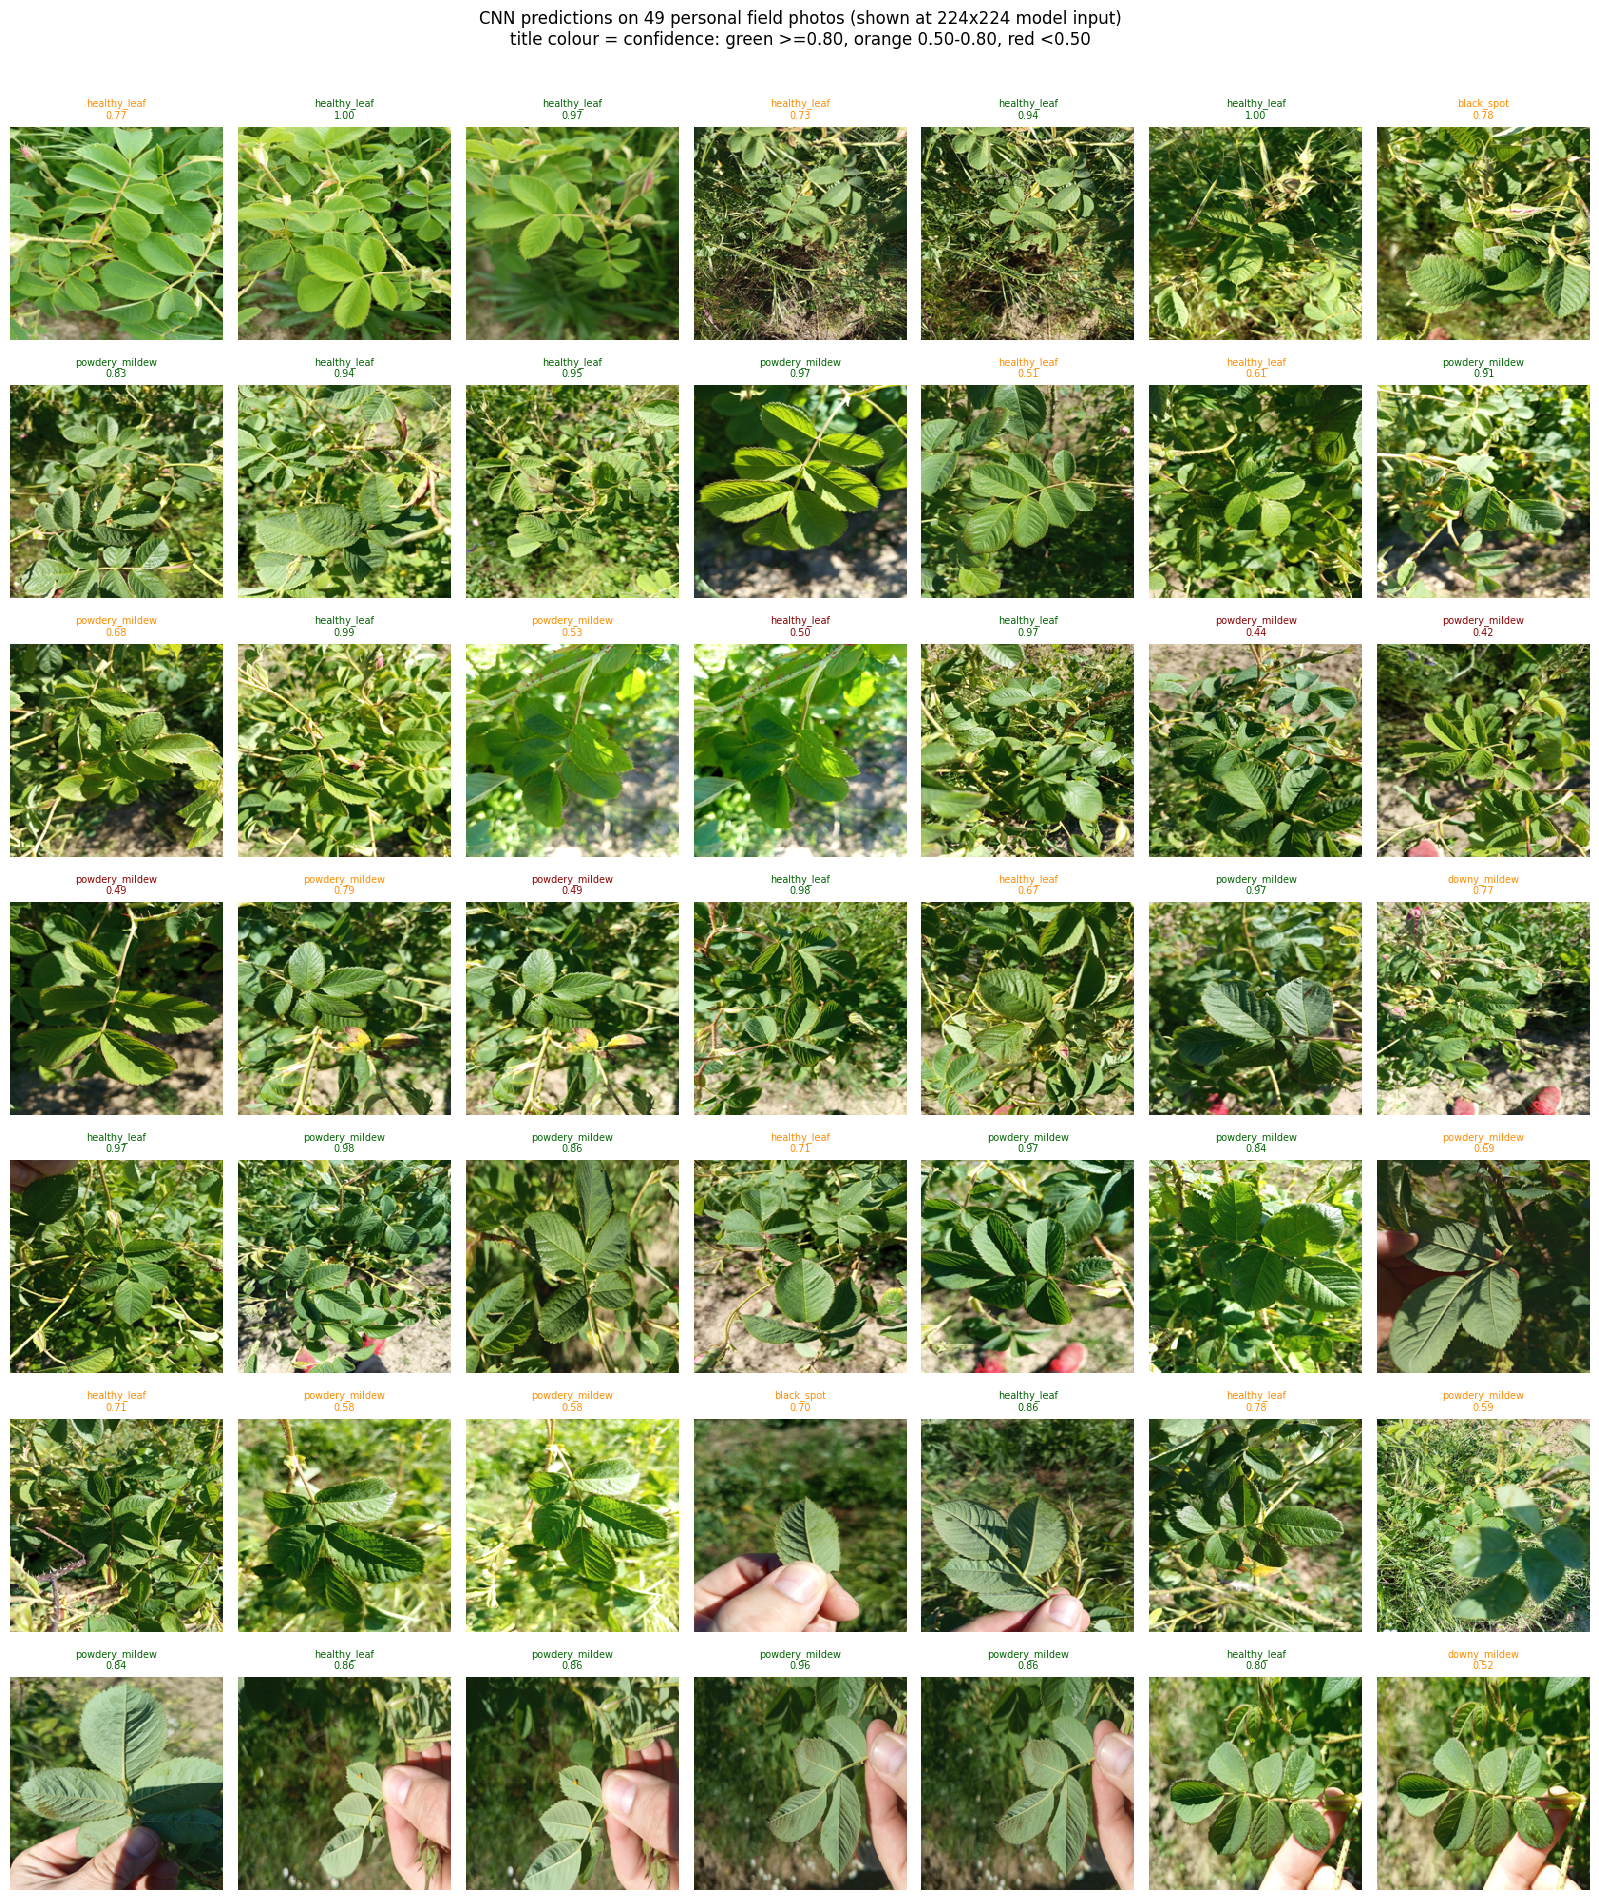

In [8]:
# ============================================================
# Grid: all 49 field photos with the model's prediction + confidence
# (images shown at the 224x224 the model actually sees)
# ============================================================
n = len(photo_paths)
ncols = 7
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.3, nrows * 2.7))
axes = np.array(axes).reshape(-1)
for ax in axes:
    ax.axis("off")

for i in range(n):
    ax = axes[i]
    ax.imshow(X[i].astype("uint8"), interpolation="nearest")
    # colour the title by confidence band
    conf = pred_conf[i]
    colour = "darkgreen" if conf >= 0.80 else ("darkorange" if conf >= 0.50 else "darkred")
    ax.set_title(f"{pred_class[i]}\n{conf:.2f}", fontsize=7, color=colour)

fig.suptitle(
    "CNN predictions on 49 personal field photos (shown at 224x224 model input)\n"
    "title colour = confidence: green >=0.80, orange 0.50-0.80, red <0.50",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()

## Conclusions - Field Test

This notebook applied the project's image classifier (CNN EfficientNetB3,
notebook 07) to 49 personal phone photos taken at the Krasnovo site in May
2026. The photos are **unlabelled**, so this is a **qualitative** test - no
formal accuracy is computed.

### The Pipeline Is Correct - the Errors Are Not Bugs

Before interpreting anything, the inference pipeline was verified on the
**labelled** test set: the model scored **0.9964** on a stratified sample
(per-class ~1.00), reproducing notebook 07's 0.9822. Crucially, `rose_rust`
scored **1.00 in-distribution** - the model demonstrably *can* recognise rust
on cropped single leaves. So everything observed below is the model's genuine
behaviour, not a loading or preprocessing fault.

### Finding 1 - A Real Discrepancy Between Prediction and Reality

Even without formal labels, a clear mismatch is visible by eye: on several
photos that show an **unmistakable rust symptom**, the model predicts
**`powdery_mildew`** (or `healthy_leaf`) instead of `rose_rust`. More broadly,
although rust was actually observed in the field in mid-May, the model
predicts **almost no rust** across the 49 photos, defaulting mostly to
`healthy_leaf` and `powdery_mildew`. This contradicts both the on-site
observation and the visible symptoms - a real, qualitative error, despite the
model's perfect rust recall on cropped leaves.

### Finding 2 - The Model Is Confidently Wrong

The wrong predictions are not hesitant: mean confidence across the photos is
**~0.78**, with many misclassifications made at **0.90-1.00**. The model
assigns **high confidence to predictions that are visibly incorrect**. This is
a well-known and important failure mode: a classifier pushed onto
**out-of-distribution** input does not "know" it is uncertain - its softmax
output stays sharp, so confidence is *not* a reliable signal of correctness
here. A high-confidence prediction on a field photo cannot be trusted on
confidence alone.

### Why This Happens - Domain Shift

The cause is the gap between training and deployment data:

- The CNN was trained on **cropped, single-leaf images at 224x224**, where a
  disease lesion fills much of the frame.
- These field photos are **whole-plant shots** - multiple compound leaves,
  hands, grass and soil in frame, variable lighting and scale.

Rust pustules that are obvious on a single-leaf close-up become small,
off-centre, or mixed with background in a wide shot, so the model latches onto
other cues and misreads the disease. The same domain shift explains the drift
toward `healthy_leaf` and `powdery_mildew`.

### Limitations (stated honestly)

- The photos are unlabelled, so the discrepancy is described qualitatively and
  cannot be quantified. The only ground truth is the photographer's own
  observation of rust in mid-May and the visible symptoms.
- The set is small (49 photos) and from two days. No expert annotation was
  performed - labelling fine-grained disease symptoms reliably requires domain
  expertise.

### Next Steps to Make the Model Field-Ready

1. **Collect and expertly label** a proper field dataset (the limiting factor
   here was annotation expertise/time, not the method).
2. **Add a detection/cropping stage** - a leaf or lesion detector that reduces
   a field photo to single-leaf crops matching the training distribution,
   before the classifier runs.
3. **Fine-tune on field data** once labelled, and consider **confidence
   calibration** so the model reports honest uncertainty on out-of-distribution
   input.
4. **Test-time augmentation** and explicit out-of-distribution detection to
   flag photos the model should not be trusted on.

### Closing

The project's classifier is excellent on the curated, single-leaf data it was
trained on, but this field test honestly demonstrates that it does **not yet
transfer to real whole-plant field photographs** - it both misreads the disease
and does so with unjustified confidence. Documenting this gap is the point of
the notebook: it sets clear, realistic expectations and a concrete path for
future work, rather than overstating the model's real-world readiness.
